#Variational AutoEncoder

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


### Stuff to Visualize the Latent Space ###

from IPython.display import HTML

### Seed Everything ###
torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
random.seed(0)


### Prep Dataset ###
tensor_transforms = transforms.Compose(
    [
        transforms.Resize((32,32)),
        transforms.ToTensor()
    ]
)
train_set = MNIST("../../../data/mnist/", train=True, transform=tensor_transforms,download=True)
test_set = MNIST("../../../data/mnist/", train=False, transform=tensor_transforms,download=True)


### Set Device ###
device = "cuda" if torch.cuda.is_available() else "cpu"

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.84MB/s]


In [ ]:
class LinearVariationalAutoEncoder(nn.Module):
  def __init__(self,latent_dim=2):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Linear(32*32,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,32)
    )

    self.fn_mu = nn.Linear(32,latent_dim)
    self.fn_logvar = nn.Linear(32,latent_dim)


    self.decoder = nn.Sequential(
        nn.Linear(latent_dim,64),
        nn.ReLU(),
        nn.Linear(64,128),
        nn.ReLU(),
        nn.Linear(128,32*32),
        nn.Sigmoid()
        )

  def forward_enc(self,x):
    x = self.encoder(x)


    mu = self.fn_mu(x)
    logvar = self.fn_logvar(x)
    # print(mu.shape,logvar.shape)

    sigma = torch.exp(0.5*logvar)
    noise = torch.randn_like(sigma,device=sigma.device)
    z = mu + sigma * noise
    return z, mu, logvar



  def forward_dec(self,x):
    return self.decoder(x)



  def forward(self,x):
    batch_size, channels, height, width = x.shape
    x = x.flatten(1)
    z, mu, logvar = self.forward_enc(x)

    dec = self.decoder(z)

    dec = dec.reshape(batch_size,channels,height,width)

    return z, dec, mu, logvar



model = LinearVariationalAutoEncoder()
model

LinearVariationalAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (fn_mu): Linear(in_features=32, out_features=2, bias=True)
  (fn_logvar): Linear(in_features=32, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1024, bias=True)
    (5): Sigmoid()
  )
)

# Loss Function

In [ ]:
def VAELoss(x,x_hat,mean,log_var,kl_weight=1,reconstruction_weight=1):
  pixel_mse = ((x - x_hat)**2)
  pixel_mse = pixel_mse.flatten(1)


  reconstruction_loss = pixel_mse.sum(axis=-1).mean()

  kl = (1 + log_var - mean**2 - torch.exp(log_var))
  kl_per_image = -0.5 * torch.sum(kl,dim=-1)
  kl_loss = torch.mean(kl_per_image)
  return reconstruction_loss * reconstruction_weight + kl_loss * kl_weight









x = torch.randn(4,1,32,32)
x_hat = torch.randn(4,1,32,32)
mean = torch.randn(4,2)
log_var = torch.randn(4,2)


VAELoss(x,x_hat,mean,log_var)

tensor(2062.9910)

# Training Script

In [ ]:
def train(model,
          kl_weight,
          train_set,
          test_set,
          batch_size,
          training_iterations,
          evaluation_iterations,
          model_type="VAE"):

    if model_type != "VAE": kl_weight = None

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    trainloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=8)
    testloader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=8)

    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    train_loss = []
    evaluation_loss = []

    encoded_data_per_eval = []
    train_losses = []
    evaluation_losses = []

    pbar = tqdm(range(training_iterations))

    train = True

    step_counter = 0
    while train:

        for images, labels in trainloader:

            images = images.to(device)

            if model_type == "VAE":
                encoded, decoded, mu, logvar = model(images)
                loss = VAELoss(images, decoded, mu, logvar, kl_weight)
            elif model_type == "AE":
                encoded, decoded = model(images)
                loss = torch.mean((images-decoded)**2)

            train_loss.append(loss.item())

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if step_counter % evaluation_iterations == 0:

                model.eval()

                encoded_evaluations = []

                for images, labels in testloader:

                    images = images.to(device)

                    if model_type == "VAE":
                        encoded, decoded, mu, logvar = model(images)
                        loss = VAELoss(images, decoded, mu, logvar, kl_weight)
                    elif model_type == "AE":
                        encoded, decoded = model(images)
                        loss = torch.mean((images-decoded)**2)

                    evaluation_loss.append(loss.item())

                    encoded, labels = encoded.cpu().flatten(1), labels.reshape(-1,1)

                    encoded_evaluations.append(torch.cat((encoded, labels), axis=-1))


                encoded_data_per_eval.append(torch.concatenate(encoded_evaluations).detach())

                train_loss = np.mean(train_loss)
                evaluation_loss = np.mean(evaluation_loss)

                train_losses.append(train_loss)
                evaluation_losses.append(evaluation_loss)

                train_loss = []
                evaluation_loss = []

                model.train()

            step_counter += 1
            pbar.update(1)


            if step_counter >= training_iterations:
                print("Completed Training!")
                train = False
                break

    encoded_data_per_eval = [np.array(i) for i in encoded_data_per_eval]

    print("Final Training Loss", train_losses[-1])
    print("Final Evaluation Loss", evaluation_losses[-1])

    return model, train_losses, evaluation_losses, encoded_data_per_eval

In [ ]:
models = []
encoded_datas = []



### Train our Variational AutoEncoders with different KL Weights ###
kl_weights = [1, 100]
for kl_weight in kl_weights:
    print(f"KL Weight:", kl_weight)
    model = LinearVariationalAutoEncoder()
    model, train_losses, evaluation_losses, encoded_data_per_eval = train(model,
                                                                          kl_weight=kl_weight,
                                                                          train_set=train_set,
                                                                          test_set=test_set,
                                                                          batch_size=64,
                                                                          training_iterations=25000,
                                                                          evaluation_iterations=250,
                                                                          model_type="VAE")

    models.append(model)
    encoded_datas.append(encoded_data_per_eval)

KL Weight: 1


  0%|          | 0/25000 [00:00<?, ?it/s]

Completed Training!
Final Training Loss 36.96724031066895
Final Evaluation Loss 37.66483261934511
KL Weight: 100


  0%|          | 0/25000 [00:00<?, ?it/s]

Completed Training!
Final Training Loss 57.60684356689453
Final Evaluation Loss 58.16757603056112


# Comparing Latents

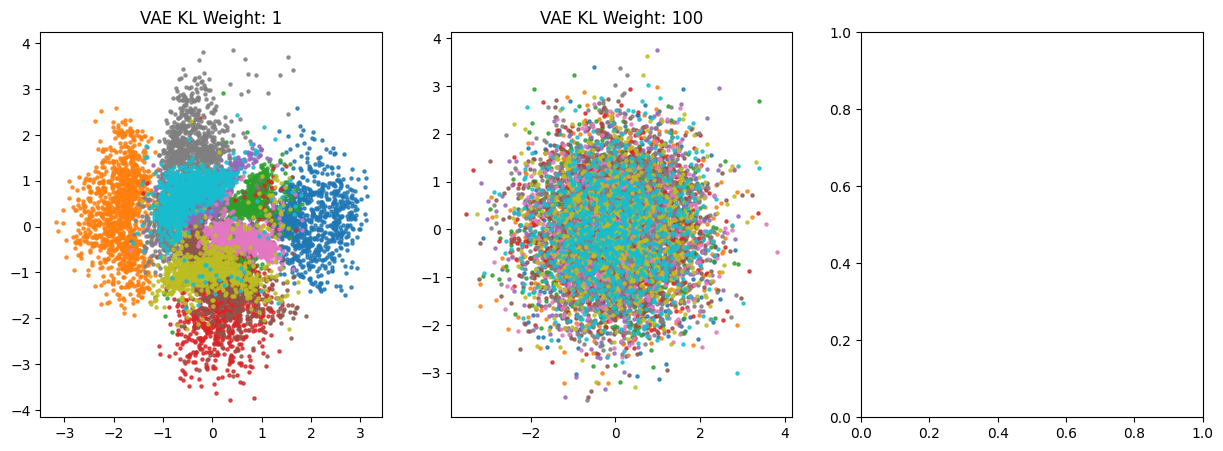

In [ ]:
model_latents = [x[-1] for x in encoded_datas]
model_names = ["VAE KL Weight: 1", "VAE KL Weight: 100"]

fig, ax = plt.subplots(1,3,figsize=(15,5))

for idx, encoding in enumerate(model_latents):
  encoding = pd.DataFrame(encoding,columns=['x','y','class'])
  encoding = encoding.sort_values(by='class')
  encoding['class'] = encoding['class'].astype(int).astype(str)

  for grouper, group in encoding.groupby('class'):
    ax[idx].scatter(x=group['x'],y=group['y'],label=grouper,alpha=0.8,s=5)

    ax[idx].set_title(model_names[idx])


vae, _ = models


In [ ]:
z = torch.tensor([0,0]).unsqueeze(0).type(torch.float32)

with torch.no_grad():
  generated = vae.forward_dec(z)


generated = generated.cpu().reshape(32,32).numpy()

plt.imshow(generated, cmap='gray')
plt.show()

torch.Size([2])

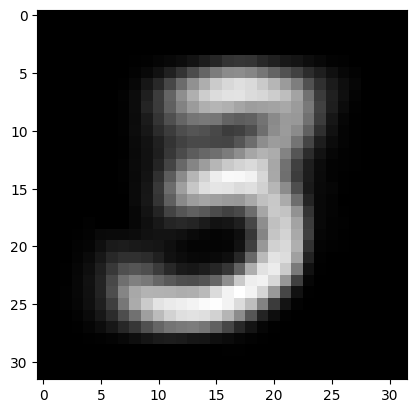

In [ ]:
z = torch.tensor([0,-2]).unsqueeze(0).type(torch.float32)

with torch.no_grad():
  generated = vae.forward_dec(z)


generated = generated.cpu().reshape(32,32).numpy()

plt.imshow(generated, cmap='gray')
plt.show()

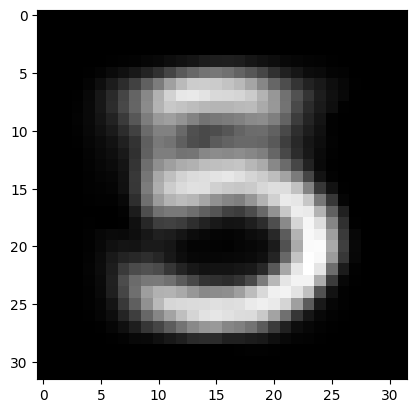

In [ ]:
z = torch.tensor([1,-2]).unsqueeze(0).type(torch.float32)

with torch.no_grad():
  generated = vae.forward_dec(z)


generated = generated.cpu().reshape(32,32).numpy()

plt.imshow(generated, cmap='gray')
plt.show()

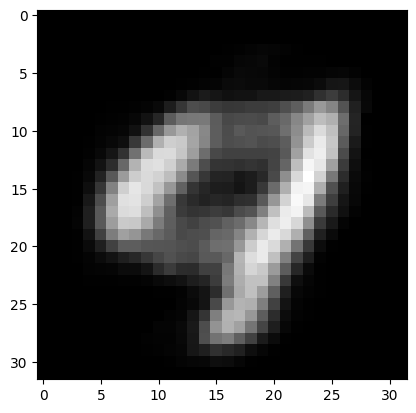

In [ ]:
z = torch.tensor([1,2]).unsqueeze(0).type(torch.float32)

with torch.no_grad():
  generated = vae.forward_dec(z)


generated = generated.cpu().reshape(32,32).numpy()

plt.imshow(generated, cmap='gray')
plt.show()

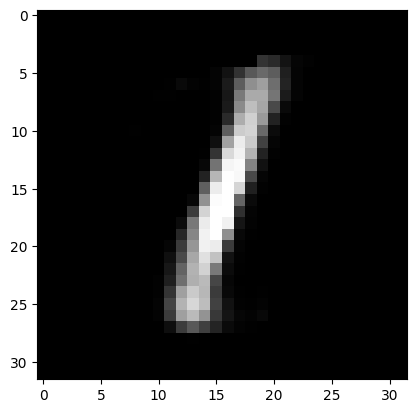

In [ ]:
z = torch.tensor([-3,0]).unsqueeze(0).type(torch.float32)

with torch.no_grad():
  generated = vae.forward_dec(z)


generated = generated.cpu().reshape(32,32).numpy()

plt.imshow(generated, cmap='gray')
plt.show()

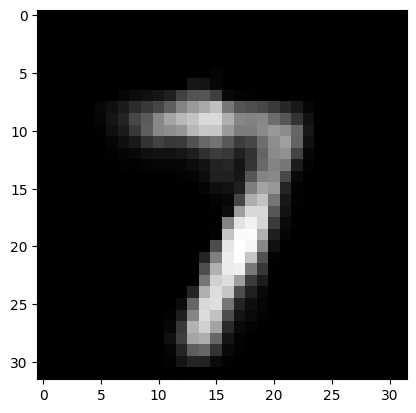

In [ ]:
z = torch.randn(1,2).type(torch.float32)

with torch.no_grad():
  generated = vae.forward_dec(z)


generated = generated.cpu().reshape(32,32).numpy()

plt.imshow(generated, cmap='gray')
plt.show()

# Convolutional Variational AutoEncoder

In [ ]:
class ConvolutionalAutoEncoder(nn.Module):

  def __init__(self,in_channels=1,channels_bottleneck=4):
    super().__init__()

    self.bottleneck = channels_bottleneck
    self.in_channels = in_channels
    self.encoder_conv = nn.Sequential(

            ### Convolutional Encoding ###
            nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(in_channels=16, out_channels=self.bottleneck, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(self.bottleneck),
            nn.ReLU(),


        )
    self.conv_mu = nn.Conv2d(in_channels=32,out_channels=self.bottleneck,kernel_size=1,stride=1)
    self.conv_logvar = nn.Conv2d(in_channe)

  def forward_enc(self,x):
    x = self.encoder_conv(x)
    print(x.shape)

  def forward(self,x):
    self.forward_enc(x)


model = ConvolutionalAutoEncoder()
rand = torch.randn(4,1,32,32)

model(rand)

torch.Size([4, 4, 4, 4])
